# Validation 07 — Parameter Calculation Timing (Cell 19)
Verifies timing measurement logic and that RMS is faster than Welch.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


In [2]:
def load_wav(path):
    fs,data=wavfile.read(path)
    if data.ndim>1: data=data[:,0]
    if   data.dtype==np.int16:  sig=data.astype(np.float64)/32768.0
    elif data.dtype==np.int32:  sig=data.astype(np.float64)/2147483648.0
    else:                       sig=data.astype(np.float64)
    return fs,sig,len(sig)/fs

def detect_onset(signal,fs):
    hop=int(ENERGY_WINDOW_S*fs); n=len(signal)//hop
    rms=np.array([np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2)) for i in range(n)])
    nf=np.mean(rms[:max(1,int(NOISE_DURATION_S/ENERGY_WINDOW_S))])
    ab=np.where(rms>ONSET_THRESHOLD*nf)[0]
    of=int(ab[0]) if len(ab) else int(np.argmax(rms))
    return of*hop, of*ENERGY_WINDOW_S, np.arange(n)*ENERGY_WINDOW_S, rms, nf

def make_windows(signal,fs):
    wl=int(WINDOW_DURATION_S*fs); sl=int(WINDOW_STEP_S*fs)
    n=max(0,(len(signal)-wl)//sl+1)
    return [signal[i*sl:i*sl+wl] for i in range(n)], np.arange(n)*WINDOW_STEP_S

def design_filter(ftype,order,lo,hi,fs):
    nyq=fs/2.; Wn=[lo/nyq,hi/nyq]
    if ftype=='Butterworth':  return butter(order,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev I':  return cheby1(order,CHEBY1_RIPPLE_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev II': return cheby2(order,CHEBY2_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Elliptical':   return ellip(order,ELLIP_RIPPLE_DB,ELLIP_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Bessel':       return bessel(order,Wn,btype='bandpass',output='sos',norm='phase')

all_wavs = sorted(set(DATA_DIR.rglob("*.wav"))|set(DATA_DIR.rglob("*.WAV")))
def skey(p):
    s=Path(p).stem.split('_')[-1]
    return SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99
all_wavs = sorted(all_wavs,key=skey)
EXAMPLE_WAV = all_wavs[0] if all_wavs else None
print(f"WAV files found: {len(all_wavs)}")
if EXAMPLE_WAV: print(f"Using: {EXAMPLE_WAV.name}")


WAV files found: 1568
Using: G80_8_3_0_AccAxial4507.wav


  [PASS]  All timing values positive
  [PASS]  RMS faster than Band Power (Welch)  → RMS=819.4μs vs Welch=12633.3μs
  [PASS]  Filter timing is measurable (>0.1μs)
  [PASS]  CF faster than Welch
  [PASS]  Averaged over 200 reps
  [INFO]  Filter (sosfiltfilt): 7849.99 μs
  [INFO]  RMS: 819.44 μs
  [INFO]  Peak: 611.41 μs
  [INFO]  Crest Factor: 1401.41 μs
  [INFO]  Zero Crossing Rate: 2417.14 μs
  [INFO]  Band Power (Welch): 12633.27 μs
  [INFO]  Spectral Centroid: 12579.50 μs
  [INFO]  Total per window: 38312.1 μs = 38.312 ms


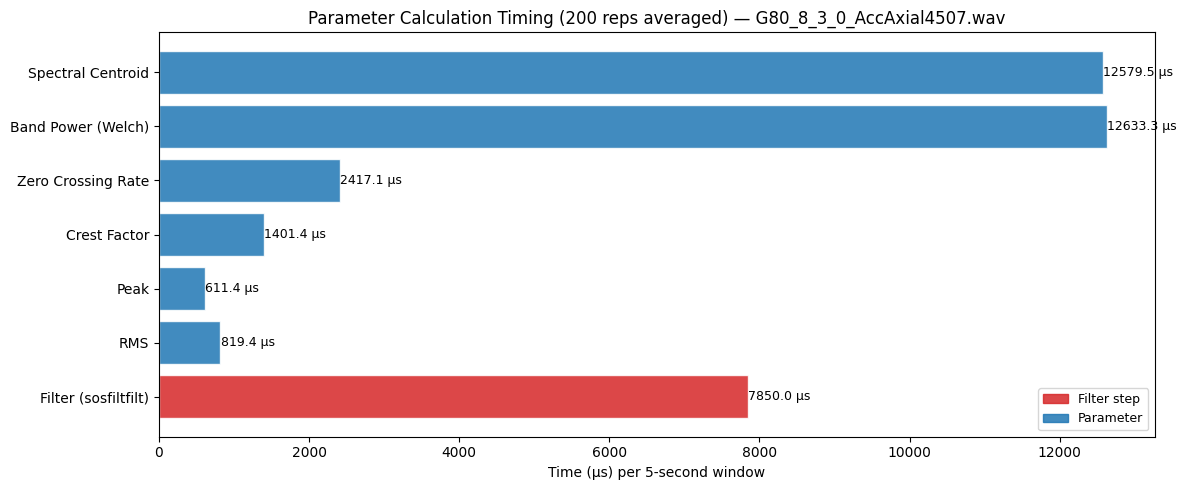


  PASS: 5/5  |  FAIL: 0/5
  Score: 100%


In [3]:
import matplotlib.patches as mpatches
if not EXAMPLE_WAV: raise SystemExit
fs,signal,_ = load_wav(EXAMPLE_WAV)
_,onset_t,_,_,_=detect_onset(signal,fs)
useful=signal[int((onset_t+ONSET_OFFSET_S)*fs):]
wins,_=make_windows(useful,fs)
if not wins: print("[SKIP] No windows"); raise SystemExit

demo_sos=design_filter('Butterworth',5,10,1000,fs)
x_demo=sosfiltfilt(demo_sos,wins[0])
N=200

param_fns={
    'Filter (sosfiltfilt)': lambda x: sosfiltfilt(demo_sos,wins[0]),
    'RMS'                 : lambda x: np.sqrt(np.mean(x**2)),
    'Peak'                : lambda x: float(np.max(np.abs(x))),
    'Crest Factor'        : lambda x: float(np.max(np.abs(x)))/max(float(np.sqrt(np.mean(x**2))),1e-12),
    'Zero Crossing Rate'  : lambda x: np.sum(np.abs(np.diff(np.sign(x)))>0)/(2.0*(len(x)-1)/fs),
    'Band Power (Welch)'  : lambda x: float(np.trapz(*reversed(welch(x,fs=fs,nperseg=min(1024,len(x)//4))))),
    'Spectral Centroid'   : lambda x: (lambda fp,ps: float(np.sum(fp*ps)/max(np.sum(ps),1e-12)))(*welch(x,fs=fs,nperseg=min(1024,len(x)//4))),
}
timings={}
for name,fn in param_fns.items():
    fn(x_demo)  # warm up
    tl=[]
    for _ in range(N):
        t0=time.perf_counter(); fn(x_demo); tl.append((time.perf_counter()-t0)*1e6)
    timings[name]=np.mean(tl)

check("All timing values positive",          all(v>0 for v in timings.values()))
check("RMS faster than Band Power (Welch)",  timings['RMS']<timings['Band Power (Welch)'],
      f"RMS={timings['RMS']:.1f}μs vs Welch={timings['Band Power (Welch)']:.1f}μs")
check("Filter timing is measurable (>0.1μs)",timings['Filter (sosfiltfilt)']>0.1)
check("CF faster than Welch",               timings['Crest Factor']<timings['Band Power (Welch)'])
check(f"Averaged over {N} reps",            N==200)

for name,val in timings.items(): info(f"{name}", f"{val:.2f} μs")
info("Total per window", f"{sum(timings.values()):.1f} μs = {sum(timings.values())/1000:.3f} ms")

fig,ax=plt.subplots(figsize=(12,5))
names=list(timings.keys()); vals=list(timings.values())
cb=['#d62728' if 'Filter' in n else '#1f77b4' for n in names]
bars=ax.barh(names,vals,color=cb,alpha=0.85,edgecolor='white')
for bar,v in zip(bars,vals): ax.text(v+0.5,bar.get_y()+bar.get_height()/2,f'{v:.1f} μs',va='center',fontsize=9)
ax.set_xlabel('Time (μs) per 5-second window')
ax.set_title(f'Parameter Calculation Timing ({N} reps averaged) — {EXAMPLE_WAV.name}')
patches=[mpatches.Patch(color='#d62728',alpha=0.85,label='Filter step'),
         mpatches.Patch(color='#1f77b4',alpha=0.85,label='Parameter')]
ax.legend(handles=patches,fontsize=9)
plt.tight_layout(); plt.show(); plt.close('all')
summary()
